# 03. Эталон: правило `classify_dot`

## Суть эталона

Здесь **не** обучаемый ML-классификатор, а **фиксированные правила** (функции `classify_dot` / расстояние до берега, вода/суша). Модель не подбирает веса; метрики показывают, «насколько хорошо удаётся описать данные простыми порогами».

In [1]:
from pathlib import Path
import sys
import os

for _p in (Path.cwd(), Path.cwd().parent):
    if (_p / "src" / "helpers.py").is_file():
        sys.path.insert(0, str((_p / "src").resolve()))
        os.chdir(_p)
        break

In [ ]:
from helpers import init_notebook_path, ensure_dirs, PROJECT_ROOT, PLOT_DIR, DATA_DIR, RANDOM_STATE
ROOT = init_notebook_path()
ensure_dirs()
print("PROJECT_ROOT", PROJECT_ROOT)

In [3]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from helpers import (
    GLOBAL_DATASET_PATH,
    DATA_DIR,
    classification_metrics_dict,
    print_report,
    append_metrics_store,
    PLOT_DIR,
    CLASS_NAMES,
    RANDOM_STATE,
)

In [4]:
df = pd.read_parquet(GLOBAL_DATASET_PATH)

if 'elevation' not in df.columns:
    df = df.copy()
    df['elevation'] = np.where(df['is_land'] >= 0.5, 1.0, -1.0)
    
le = pickle.load(open(DATA_DIR / 'label_encoder.pkl', 'rb'))
y_all = le.transform(df['target_class'])

In [5]:
def missing_dist(row):
    dist = row["distance_to_coast_km"]
    if pd.isna(dist):
        dist = 999.0
    return float(dist)


def classify_dot(row):
    dist = missing_dist(row)
    elev = row["elevation"]
    if elev < 0:
        if dist > 20:
            return "OPEN_SEA"
        return "COASTAL_SEA"
    if dist <= 1:
        return "COASTLINE"
    return "NEAR_COAST"
    
    

## Как читать метрики

Тот же `classification_report` и тот же `y_test`, что и у остальных моделей. Сравнение с ML — по accuracy / macro F1; эталон удобен как **простой ориентир** и для проверки согласованности разметки с правилами.

In [6]:
pred_str = df.apply(classify_dot, axis=1)
y_pred = le.transform(pred_str)
m = classification_metrics_dict(y_all, y_pred)
print(m)
print_report(y_all, y_pred)

{'accuracy': 1.0, 'precision_macro': 1.0, 'recall_macro': 1.0, 'f1_macro': 1.0, 'precision_micro': 1.0, 'recall_micro': 1.0, 'f1_micro': 1.0}
              precision    recall  f1-score   support

    OPEN_SEA       1.00      1.00      1.00      2000
 COASTAL_SEA       1.00      1.00      1.00      2000
  NEAR_COAST       1.00      1.00      1.00      2000
   COASTLINE       1.00      1.00      1.00      2000

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



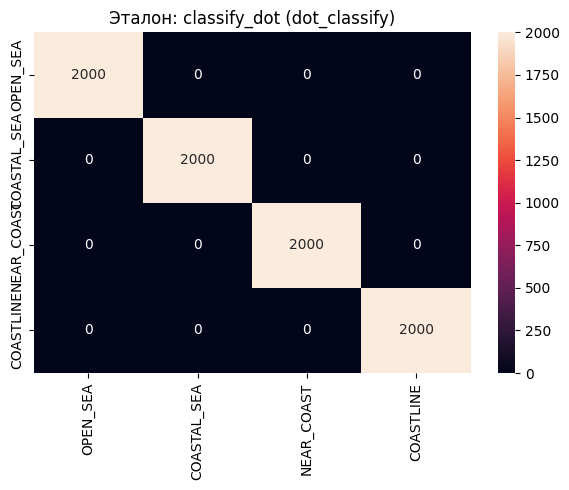

In [7]:
append_metrics_store('linear_classify_dot', m)
cm = confusion_matrix(y_all, y_pred, labels=np.arange(len(CLASS_NAMES)))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Эталон: classify_dot (dot_classify)')
plt.tight_layout(); plt.savefig(PLOT_DIR / 'confusion_linear.png', dpi=150)
plt.show()
plt.close()